## Cargamos los datos segmentados

In [ ]:
import pandas as pd
import numpy as np
import joblib
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

base_path = "/content/drive/MyDrive/Colab Notebooks/data/"
file_path = base_path + "segments_dataset_con_id.csv"

df = pd.read_csv(file_path)



In [ ]:
df.shape

(1523121, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1523121 entries, 0 to 1523120
Data columns (total 23 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   segment_id         1523121 non-null  int64  
 1   MMSI               1523121 non-null  int64  
 2   trajectory_id      1523121 non-null  int64  
 3   speed_mean         1523121 non-null  float64
 4   speed_std          1523121 non-null  float64
 5   speed_max          1523121 non-null  float64
 6   delta_course_mean  1523121 non-null  float64
 7   delta_course_max   1523121 non-null  float64
 8   turning_rate_mean  1523121 non-null  float64
 9   turning_rate_max   1523121 non-null  float64
 10  acceleration_mean  1523121 non-null  float64
 11  acceleration_max   1523121 non-null  float64
 12  delta_t_mean       1523121 non-null  float64
 13  delta_t_max        1523121 non-null  float64
 14  distance_km        1523121 non-null  float64
 15  duration           1523121 non-n

In [ ]:
df.isna().sum()

,0
segment_id,0
MMSI,0
trajectory_id,0
speed_mean,0
speed_std,0
speed_max,0
delta_course_mean,0
delta_course_max,0
turning_rate_mean,0
turning_rate_max,0


In [ ]:
df["ship_type"].value_counts()

,count
ship_type,
Special_Craft,834761
Service,313816
Cargo,133961
Passenger,95419
Tanker,68487
Other,46351
Undefined,20522
High_Speed,7053
WIG,2375


## Feature Engineering

Isolation Forest funciona mejor cuando detecta comportamientos dinámicos, no solo posiciones.

Las variables utilizadas se agrupan en tres categorías:
1. Características cinemáticas básicas (velocidad, aceleración, cambio de rumbo),
2.  Medidas de variabilidad e inestabilidad del movimiento, y
3.  Variables derivadas basadas en conocimiento del dominio marítimo. [1]

Este enfoque es consistente con la literatura en detección de anomalías en trayectorias AIS, donde se combinan métricas estadísticas con heurísticas específicas del dominio para mejorar la interpretabilidad de los resultados.

[1] Xu, S., Huang, L., Huang, Y., Wen, Y., Cheng, X., & van Gelder, P. H. A. J. M. (2025). A framework for ship semantic behavior representation and indexing. Ocean Engineering, 329, 121023. https://doi.org/10.1016/j.oceaneng.2025.121023



**Inestabilidad de rumbo**

Captura desviaciones bruscas en el rumbo, asociadas a maniobras inusuales

In [ ]:
df["course_instability"] = df["delta_course_max"] - df["delta_course_mean"]

**Coeficiente de variación de velocidad**

Permite medir la variabilidad relativa de la velocidad, útil para detectar comportamientos irregulares

In [ ]:
df["speed_cv"] = df["speed_std"] / (df["speed_mean"] + 1e-6)

**Intensidad de giro**

In [ ]:
df["turning_intensity"] = df["delta_course_mean"] / (df["delta_t_mean"] + 1e-6)

**Variación de velocidad**

In [ ]:
df["speed_variation"] = df["speed_max"] - df["speed_mean"]

**Velocidad media real del segmento en km/h**

In [ ]:
df["avg_speed_kmh"] = df["distance_km"] / (df["duration"] / 3600 + 1e-6)

**Irregularidad temporal AIS**

Mide irregularidades en la transmisión AIS, asociadas en algunos casos a manipulación o pérdida de señal

In [ ]:
df["ais_gap"] = df["delta_t_max"] / (df["delta_t_mean"] + 1e-6)

**Inestabilidad de aceleración**

In [ ]:
df["acceleration_instability"] = df["acceleration_max"] - df["acceleration_mean"]

**Ratio de giro**

Refleja la intensidad relativa de los cambios de dirección

In [ ]:
df["turning_ratio"] = df["turning_rate_max"] / (df["turning_rate_mean"] + 1e-6)

**Indicadores orientados a dominio**

En esta sección no se aplican todavía reglas marítimas finales ni validación experta.  
Lo que se construye aquí son **indicadores de comportamiento inspirados en el dominio marítimo**, que después podrán usarse en tres sitios:

- como variables de entrada para los modelos no supervisados,
- como señales auxiliares para la capa experta basada en reglas,
- y como variables interpretables para clustering y ranking.

Por tanto, estas variables no constituyen todavía el sistema híbrido final, sino la preparación de las señales que alimentarán las siguientes fases.

In [ ]:
df["slow_motion"] = (df["speed_mean"] < 1).astype(int)
df["high_speed_flag"] = (df["speed_max"] > 25).astype(int)
df["low_distance_flag"] = (df["distance_km"] < 0.5).astype(int)

# Indicadores adicionales útiles para la futura capa experta
df["points_density"] = 1 / (df["delta_t_mean"] + 1e-6)
df["erratic_motion_flag"] = (
    (df["course_instability"] > df["course_instability"].quantile(0.90)) &
    (df["turning_intensity"] > df["turning_intensity"].quantile(0.90))
).astype(int)

df["stop_like_flag"] = (
    (df["speed_mean"] < 0.5) &
    (df["distance_km"] < 0.2) &
    (df["duration"] > 600)
).astype(int)

In [ ]:
new_cols = [
    "course_instability",
    "speed_cv",
    "turning_intensity",
    "speed_variation",
    "avg_speed_kmh",
    "ais_gap",
    "acceleration_instability",
    "turning_ratio",
    "slow_motion",
    "high_speed_flag",
    "low_distance_flag",
    "points_density",
    "erratic_motion_flag",
    "stop_like_flag"
]

df[new_cols].head()

,course_instability,speed_cv,turning_intensity,speed_variation,avg_speed_kmh,ais_gap,acceleration_instability,turning_ratio,slow_motion,high_speed_flag,low_distance_flag,points_density,erratic_motion_flag,stop_like_flag
0,52.275000,1.170570,0.441797,0.66,0.140570,2.182292,0.007764,1.655017,1,0,1,0.005208,0,0
1,90.575000,0.998260,0.524701,0.92,0.102305,1.095808,0.009098,1.787201,1,0,1,0.005988,0,1
2,50.550000,0.818486,0.819320,0.76,0.097208,1.174583,0.009868,1.626415,1,0,1,0.006418,0,0
3,44.560000,0.734229,0.278392,0.35,0.283949,2.925577,0.003706,2.836327,1,0,1,0.005133,0,0
4,59.716667,1.168362,0.303644,0.50,0.118574,1.406215,0.005299,3.706656,1,0,1,0.007769,0,1


In [ ]:
base_features = [
    "speed_mean",
    "speed_std",
    "speed_max",
    "delta_course_mean",
    "delta_course_max",
    "turning_rate_mean",
    "turning_rate_max",
    "acceleration_mean",
    "acceleration_max",
    "delta_t_mean",
    "delta_t_max",
    "distance_km",
    "duration"
]

derived_features = [
    "course_instability",
    "speed_cv",
    "turning_intensity",
    "speed_variation",
    "avg_speed_kmh",
    "ais_gap",
    "acceleration_instability",
    "turning_ratio"
]

domain_features = [
    "slow_motion",
    "high_speed_flag",
    "low_distance_flag",
    "points_density",
    "erratic_motion_flag",
    "stop_like_flag"
]

feature_cols = base_features + derived_features + domain_features

print("Base features:", len(base_features))
print("Derived features:", len(derived_features))
print("Domain-inspired features:", len(domain_features))
print("Total features:", len(feature_cols))


Base features: 13
Derived features: 8
Domain-inspired features: 6
Total features: 27


Las variables utilizadas en el modelado se organizan en tres bloques:

- **Base features**: variables cinemáticas y temporales extraídas directamente de cada segmento.
- **Derived features**: variables derivadas que resumen inestabilidad, variación o irregularidad del comportamiento.
- **Domain-inspired features**: indicadores interpretables inspirados en conocimiento marítimo, que más adelante alimentarán la capa experta basada en reglas.

Esta separación será útil más adelante para comparar subconjuntos de variables, realizar selección de modelo y construir el sistema híbrido final.

## Train/Test split

La partición del conjunto de datos se realizó a nivel de trayectoria en lugar de a nivel de segmento individual, con el objetivo de evitar leakage de información entre entrenamiento y test. Este enfoque permite evaluar la capacidad del modelo para generalizar a trayectorias no vistas previamente, lo cual es más representativo de un escenario real.

In [ ]:
trajectory_keys = (
    df[["MMSI", "trajectory_id"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Número de trayectorias únicas:", len(trajectory_keys))
trajectory_keys.head()

Número de trayectorias únicas: 17826


,MMSI,trajectory_id
0,0,0
1,1056261,0
2,1056261,3
3,1056261,5
4,123456789,0


Se asignó un identificador único a cada trayectoria juntando el MMSI con el trajectory_id. Para la división en train y test, se tuvo cuidado de no separar los segmentos de una misma trayectoria entre los dos conjuntos. De esta forma, la evaluación del modelo refleja mejor un escenario real.

In [ ]:
train_keys, test_keys = train_test_split(
    trajectory_keys,
    test_size=0.2,
    random_state=42
)

print("Train trajectories:", len(train_keys))
print("Test trajectories:", len(test_keys))

Train trajectories: 14260
Test trajectories: 3566


In [ ]:
train_df = df.merge(train_keys, on=["MMSI", "trajectory_id"], how="inner")
test_df = df.merge(test_keys, on=["MMSI", "trajectory_id"], how="inner")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1228043, 37)
Test shape: (295078, 37)


In [ ]:
print("Segmentos por split")
print("-------------------")
print("Train segments:", len(train_df))
print("Test segments:", len(test_df))
print()

print("Trayectorias únicas por split")
print("-----------------------------")
print("Train trajectories:", train_df[["MMSI", "trajectory_id"]].drop_duplicates().shape[0])
print("Test trajectories:", test_df[["MMSI", "trajectory_id"]].drop_duplicates().shape[0])
print()

print("Distribución ship_type en train:")
print(train_df["ship_type"].value_counts(normalize=True).round(3))
print()

print("Distribución ship_type en test:")
print(test_df["ship_type"].value_counts(normalize=True).round(3))

Segmentos por split
-------------------
Train segments: 1228043
Test segments: 295078

Trayectorias únicas por split
-----------------------------
Train trajectories: 14260
Test trajectories: 3566

Distribución ship_type en train:
ship_type
Special_Craft    0.542
Service          0.210
Cargo            0.089
Passenger        0.063
Tanker           0.046
Other            0.031
Undefined        0.014
High_Speed       0.004
WIG              0.001
Unknown          0.000
Name: proportion, dtype: float64

Distribución ship_type en test:
ship_type
Special_Craft    0.573
Service          0.190
Cargo            0.085
Passenger        0.061
Tanker           0.041
Other            0.029
Undefined        0.013
High_Speed       0.006
WIG              0.002
Name: proportion, dtype: float64


Comprobación de data leakage

In [ ]:
train_traj = set(map(tuple, train_df[["MMSI", "trajectory_id"]].drop_duplicates().values))
test_traj = set(map(tuple, test_df[["MMSI", "trajectory_id"]].drop_duplicates().values))

intersection = train_traj.intersection(test_traj)
print("Trayectorias compartidas entre train y test:", len(intersection))

Trayectorias compartidas entre train y test: 0


Matrices para el modelo

In [ ]:
X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train_meta = train_df[["MMSI", "trajectory_id", "segment_id", "ship_type"]].copy()
y_test_meta = test_df[["MMSI", "trajectory_id", "segment_id", "ship_type"]].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1228043, 27)
X_test shape: (295078, 27)


In [ ]:
print("Valores infinitos en features:", np.isinf(df[feature_cols]).sum().sum())
print("Valores nulos en features:", df[feature_cols].isna().sum().sum())

df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
df[feature_cols] = df[feature_cols].fillna(0)

print("Tras limpieza:")
print("Valores infinitos:", np.isinf(df[feature_cols]).sum().sum())
print("Valores nulos:", df[feature_cols].isna().sum().sum())

Valores infinitos en features: 0
Valores nulos en features: 0
Tras limpieza:
Valores infinitos: 0
Valores nulos: 0


Escalado

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)

(1228043, 27) (295078, 27)


In [ ]:
scaled_train_df = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
scaled_test_df = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

scaled_train_df.head()

,speed_mean,speed_std,speed_max,delta_course_mean,delta_course_max,turning_rate_mean,turning_rate_max,acceleration_mean,acceleration_max,delta_t_mean,...,avg_speed_kmh,ais_gap,acceleration_instability,turning_ratio,slow_motion,high_speed_flag,low_distance_flag,points_density,erratic_motion_flag,stop_like_flag
0,-0.398100,-0.254081,-0.427144,-0.562840,-0.606812,-0.446165,-0.209018,0.002095,-0.070312,-0.618796,...,-0.027884,0.035040,-0.075188,3.578600,0.467533,-0.038716,0.458751,0.714274,-0.216294,0.541313
1,-0.389822,-0.143588,-0.348111,-0.562840,-0.606812,-0.446165,-0.209018,0.021045,0.003187,-0.637997,...,-0.027815,0.069949,-0.001019,3.578600,0.467533,-0.038716,0.458751,0.772166,-0.216294,0.541313
2,-0.390511,-0.147852,-0.348111,-0.563619,-0.606812,-0.447092,-0.209018,0.019323,0.003187,-0.742499,...,-0.027814,0.286442,-0.000658,4.021596,0.467533,-0.038716,0.458751,1.131185,-0.216294,0.541313
3,-0.390511,-0.147852,-0.348111,-0.571409,-0.640811,-0.456360,-0.223645,0.019323,0.003187,-0.700734,...,-0.027875,0.194075,-0.000658,-0.852641,0.467533,-0.038716,0.458751,0.978009,-0.216294,0.541313
4,-0.398100,-0.254081,-0.427144,-0.571085,-0.639111,-0.455966,-0.222913,0.002095,-0.070312,-0.750454,...,-0.027827,-0.188457,-0.075188,4.847817,0.467533,-0.038716,0.458751,1.162012,-0.216294,0.541313


Correlación sobre muestra

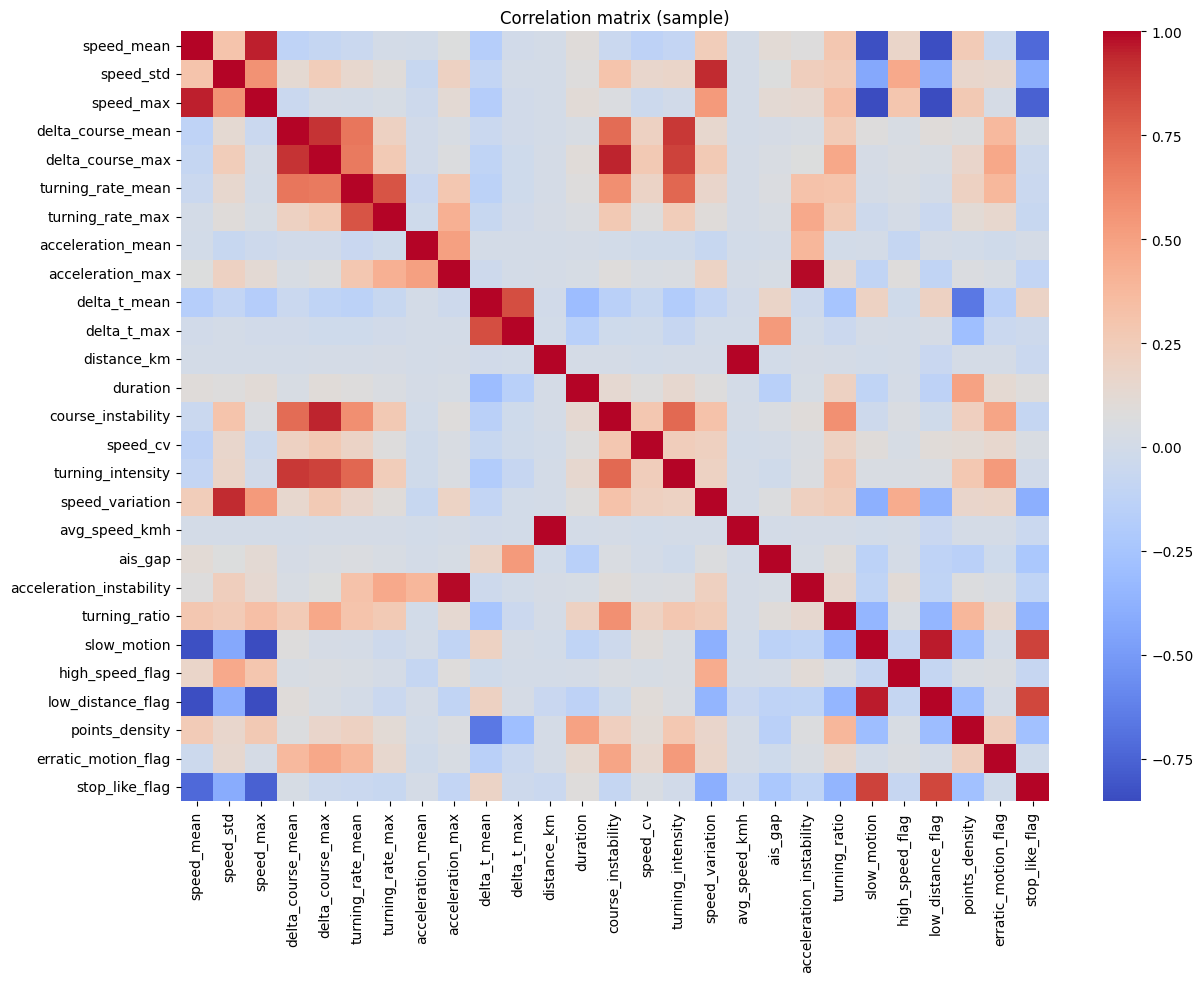

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sample_corr = df[feature_cols].sample(n=20000, random_state=42)

plt.figure(figsize=(14,10))
sns.heatmap(sample_corr.corr(), cmap="coolwarm")
plt.title("Correlation matrix (sample)")
plt.show()

La matriz de correlación muestra la existencia de grupos de variables altamente correlacionadas, especialmente entre aquellas que describen velocidad y cambios de rumbo. Este comportamiento es esperable, dado que dichas variables capturan aspectos similares del movimiento. No obstante, el modelo utilizado (Isolation Forest) es robusto frente a la multicolinealidad, por lo que no se considera necesario eliminar estas variables. Además, se observa que las variables derivadas y los indicadores binarios aportan información complementaria.

## Guardamos los datasets para el modelado

In [ ]:
base_path = "/content/drive/MyDrive/TFG/data_processed/"

In [ ]:
# Matrices escaladas para modelado
np.save(base_path + "X_train.npy", X_train_scaled)
np.save(base_path + "X_test.npy", X_test_scaled)

# Datasets completos no escalados para interpretación
train_df.to_csv(base_path + "train_segments.csv", index=False)
test_df.to_csv(base_path + "test_segments.csv", index=False)

# Versiones tabulares escaladas (útiles para revisión y experimentos)
scaled_train_df.to_csv(base_path + "train_scaled_segments.csv", index=False)
scaled_test_df.to_csv(base_path + "test_scaled_segments.csv", index=False)

# Metadatos
y_train_meta.to_csv(base_path + "train_metadata.csv", index=False)
y_test_meta.to_csv(base_path + "test_metadata.csv", index=False)

# Objetos auxiliares
joblib.dump(scaler, base_path + "scaler.pkl")
joblib.dump(feature_cols, base_path + "feature_cols.pkl")
joblib.dump(base_features, base_path + "base_features.pkl")
joblib.dump(derived_features, base_path + "derived_features.pkl")
joblib.dump(domain_features, base_path + "domain_features.pkl")

print("Archivos guardados en:", base_path)

Archivos guardados en: /content/drive/MyDrive/TFG/data_processed/


Este notebook guarda tanto versiones escaladas como no escaladas del dataset:

- Las versiones **no escaladas** se utilizarán en fases de interpretación, reglas expertas y análisis posterior.
- Las versiones **escaladas** se utilizarán en la fase de modelado no supervisado.
- También se guardan los grupos de variables para facilitar comparaciones entre conjuntos de features en la fase de selección de modelos.

In [ ]:
print("Resumen final")
print("-------------")
print("Dataset total:", df.shape)
print("Train:", train_df.shape)
print("Test:", test_df.shape)
print()

print("Número de features usadas:", len(feature_cols))
print(" - Base:", len(base_features))
print(" - Derivadas:", len(derived_features))
print(" - Inspiradas en dominio:", len(domain_features))
print()

print("Primeras 10 features:")
print(feature_cols[:10])

Resumen final
-------------
Dataset total: (1523121, 37)
Train: (1228043, 37)
Test: (295078, 37)

Número de features usadas: 27
 - Base: 13
 - Derivadas: 8
 - Inspiradas en dominio: 6

Primeras 10 features:
['speed_mean', 'speed_std', 'speed_max', 'delta_course_mean', 'delta_course_max', 'turning_rate_mean', 'turning_rate_max', 'acceleration_mean', 'acceleration_max', 'delta_t_mean']


En esta fase se ha preparado el dataset para el modelado posterior a partir de los segmentos generados en el notebook anterior.  
Primero se construyeron variables derivadas capaces de resumir comportamientos dinámicos como la inestabilidad de rumbo, la variación de velocidad o la irregularidad temporal de las emisiones AIS. Además, se añadieron indicadores interpretables inspirados en conocimiento del dominio marítimo, como señales de movimiento lento, velocidades elevadas o desplazamientos reducidos.

Después, la partición entre entrenamiento y prueba se realizó a nivel de trayectoria completa, en lugar de a nivel de segmento individual, para evitar fuga de información entre ambos conjuntos. Finalmente, se generaron y guardaron tanto las matrices escaladas para modelado como las versiones no escaladas necesarias para interpretación, validación experta y futuras fases del sistema híbrido.